In [ ]:
# Downloading the video
import yt_dlp
import json
URL = 'https://youtube.com/shorts/MwxxofLNpTg?si=3h0r0rWu7J_-zQmr'

ydl_opts = {}
with yt_dlp.YoutubeDL(ydl_opts) as ydl:
    info = ydl.extract_info(URL, download=True)

    print(json.dumps(ydl.sanitize_info(info)))


[youtube] Extracting URL: https://youtube.com/shorts/MwxxofLNpTg?si=3h0r0rWu7J_-zQmr
[youtube] MwxxofLNpTg: Downloading webpage
[youtube] MwxxofLNpTg: Downloading tv client config
[youtube] MwxxofLNpTg: Downloading player 69f581a5
[youtube] MwxxofLNpTg: Downloading tv player API JSON
[youtube] MwxxofLNpTg: Downloading ios player API JSON
[youtube] MwxxofLNpTg: Downloading m3u8 information


[info] MwxxofLNpTg: Downloading 1 format(s): 18
[download] Destination: Active Track - Near Crash ｜ DJI Mini 4 Pro #dji #mini4 #followme #drone #activetrack #wildtrak [MwxxofLNpTg].mp4
[download] 100% of    1.21MiB in 00:00:00 at 2.65MiB/s   
{"id": "MwxxofLNpTg", "title": "Active Track - Near Crash | DJI Mini 4 Pro #dji #mini4 #followme #drone #activetrack #wildtrak", "formats": [{"format_id": "sb2", "format_note": "storyboard", "ext": "mhtml", "protocol": "mhtml", "acodec": "none", "vcodec": "none", "url": "https://i.ytimg.com/sb/MwxxofLNpTg/storyboard3_L1/M$M.jpg?sqp=-oaymwENSDfyq4qpAwVwAcABBqLzl_8DBgjyzOCwBg==&sigh=rs$AOn4CLAq6HcBhylmvFF90-KwwwQWb8qJtA", "width": 25, "height": 45, "fps": 1.1333333333333333, "rows": 10, "columns": 10, "fragments": [{"url": "https://i.ytimg.com/sb/MwxxofLNpTg/storyboard3_L1/M0.jpg?sqp=-oaymwENSDfyq4qpAwVwAcABBqLzl_8DBgjyzOCwBg==&sigh=rs$AOn4CLAq6HcBhylmvFF90-KwwwQWb8qJtA", "duration": 15.0}], "audio_ext": "none", "video_ext": "none", "vbr": 0, "abr":

# Task 1

In [2]:
%pip install opencv-python ultralytics matplotlib ipython yt-dlp

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.1/172.1 kB 8.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 8.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 1.2 MB/s eta 0:00:00ta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 6.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 7.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.9/101.9 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 11.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 976.9/976.9 kB 2.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 21.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 8.6 MB/s eta 0:00:00a 0:00:01m

In [1]:
import cv2
from ultralytics import YOLO
import matplotlib.pyplot as plt
from IPython.display import display,clear_output

Extracting frames from video

In [2]:
VIDEO_PATH = r"Active Track - Near Crash ｜ DJI Mini 4 Pro #dji #mini4 #followme #drone #activetrack #wildtrak [MwxxofLNpTg].mp4"
OUTPUT_DIR = '.'

cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    print("ERROR: VIDEO NOT OPENED")
    exit()

In [9]:
model = YOLO('yolo11n.pt')
class_names = ['car','bus','truck','boat']

## Extracting each frame and Applying Tracking 

In [ ]:
frame_index = 0
boxed_frames = []
original_frames = []
detections = []
while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame = cv2.cvtColor(frame,cv2.COLOR_BGR2RGB)
    frame_copy = frame.copy()

    original_frames.append(frame.copy())

    results = model(frame)
    frame_detections = []

    for result in results[0].boxes.data:
        x1,y1,x2,y2,score,class_id = result
        print(class_id)

        if score > 0.3:
            x1,y1,x2,y2 = map(int,[x1,y1,x2,y2])
            score = float(score)
            class_id = int(class_id)
            frame_detections.append((x1, y1, x2, y2, score, class_id))
            cv2.rectangle(frame_copy,(x1,y1),(x2,y2),(0,255,0))
            label = f'({x1},{x2})'
            cv2.putText(frame_copy,label,(x1,y1-10),cv2.FONT_HERSHEY_COMPLEX,0.5,(0,255,0),2)
            print("DETECTIONS",frame_detections)
    clear_output(wait=True)
    # plt.imshow(frame_copy)
    # plt.axis("off")
    # display(plt.gcf())
    detections.append(frame_detections)
    boxed_frames.append(frame_copy)
    frame_index+=1
cap.release()
print(detections)

[[(163, 380, 203, 432, 0.3557175397872925, 6)], [(164, 380, 204, 431, 0.3249267041683197, 6)], [], [], [(164, 380, 203, 431, 0.3163931965827942, 6)], [(164, 380, 203, 431, 0.5432831048965454, 6)], [(165, 380, 203, 431, 0.33989354968070984, 6)], [(165, 380, 203, 431, 0.3547796905040741, 6)], [(165, 380, 203, 431, 0.40305158495903015, 8)], [(165, 380, 203, 430, 0.4084608554840088, 6), (165, 380, 204, 430, 0.37335896492004395, 8)], [(165, 380, 203, 430, 0.5663544535636902, 8)], [(165, 380, 204, 429, 0.6650106310844421, 8)], [(165, 379, 204, 429, 0.7744866609573364, 8)], [(165, 379, 204, 428, 0.6367709636688232, 8)], [(167, 379, 204, 429, 0.3835166096687317, 8)], [(167, 379, 204, 428, 0.3486323654651642, 8)], [(168, 380, 205, 429, 0.3085746765136719, 6)], [], [(167, 379, 205, 427, 0.3319236934185028, 6)], [(167, 379, 205, 427, 0.4188774824142456, 6)], [(168, 379, 205, 426, 0.5121705532073975, 6)], [(168, 379, 205, 426, 0.4310856759548187, 6)], [(169, 378, 206, 426, 0.43754443526268005, 6)]

In [5]:
video_name = "boxed_car.mp4"
frame_height, frame_width, _ =  boxed_frames[0].shape
fps = 30

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(video_name,fourcc,fps,(frame_width,frame_height))

for frame in boxed_frames:
    out.write(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))

out.release()

# Task 2

In [5]:
from filterpy.kalman import KalmanFilter
import numpy as np
from scipy.spatial.distance import euclidean

Initializing the boxed video and kalman filter

In [6]:
kalman_filter = KalmanFilter(dim_x = 4, dim_z=2)

In [7]:
kalman_filter.F = np.array(
    [[1,0,1,0],# predicting for x using velocity
     [0,1,0,1],# for y
     [0,0,1,0],# assuming velocity is same
     [0,0,0,1]]
    )
kalman_filter.H = np.array([
    [1,0,0,0],
    [0,1,0,0]])
kalman_filter.P *= 1000
kalman_filter.R = np.array([
    [5,0],
    [0,5]])
kalman_filter.Q = np.eye(4) * 0.1

innov_sequence = []
tracked_pos = []
detected_pos = []

Detections:  [[(163, 380, 203, 432, 0.3557175397872925, 6)], [(164, 380, 204, 431, 0.3249267041683197, 6)], [], [], [(164, 380, 203, 431, 0.3163931965827942, 6)], [(164, 380, 203, 431, 0.5432831048965454, 6)], [(165, 380, 203, 431, 0.33989354968070984, 6)], [(165, 380, 203, 431, 0.3547796905040741, 6)], [(165, 380, 203, 431, 0.40305158495903015, 8)], [(165, 380, 203, 430, 0.4084608554840088, 6), (165, 380, 204, 430, 0.37335896492004395, 8)], [(165, 380, 203, 430, 0.5663544535636902, 8)], [(165, 380, 204, 429, 0.6650106310844421, 8)], [(165, 379, 204, 429, 0.7744866609573364, 8)], [(165, 379, 204, 428, 0.6367709636688232, 8)], [(167, 379, 204, 429, 0.3835166096687317, 8)], [(167, 379, 204, 428, 0.3486323654651642, 8)], [(168, 380, 205, 429, 0.3085746765136719, 6)], [], [(167, 379, 205, 427, 0.3319236934185028, 6)], [(167, 379, 205, 427, 0.4188774824142456, 6)], [(168, 379, 205, 426, 0.5121705532073975, 6)], [(168, 379, 205, 426, 0.4310856759548187, 6)], [(169, 378, 206, 426, 0.437544435

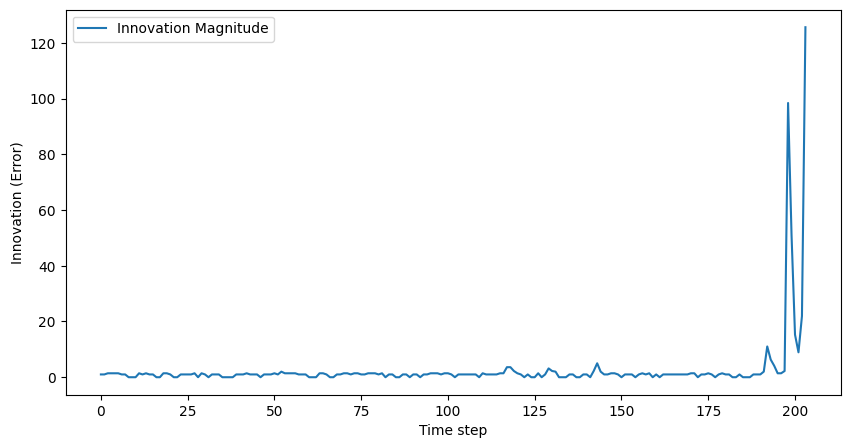

In [8]:
print("Detections: ", detections)
for frame_detections in detections:
    print(f'frame: {frame}')
    if not frame_detections:
        continue

    x1,y1,x2,y2,score,class_id = frame_detections[0]
    #print(f'DETECTIONS: {x1},{y1},{x2},{y2},{score},{class_id},')

    cx,cy = (x1+x2) // 2, (y1+y2) //2
    #print(f'CX,CY: {cx},{cy}')
    detected_pos.append([cx, cy, 0, 0])
    print("DETECTED POS = ",detected_pos)
    print(len(tracked_pos))
    if len(tracked_pos) == 0:
        kalman_filter.x = np.array([cx, cy, 0, 0])
        tracked_pos.append((cx,cy))
    else:
        kalman_filter.predict()
        kalman_filter.update(np.array([cx, cy]))

        estimate = (int(kalman_filter.x[0]), int(kalman_filter.x[1]))
        tracked_pos.append(estimate)

        innovation = euclidean((cx,cy), estimate)
        print("INNOVATION\n",innovation)
        innov_sequence.append(innovation)
plt.figure(figsize=(10, 5))
print(innov_sequence)
plt.plot(innov_sequence, label="Innovation Magnitude")
plt.xlabel("Time step")
plt.ylabel("Innovation (Error)")
plt.legend()
plt.show()

# Task 3

In [35]:
import cv2
from ultralytics import YOLO
import matplotlib.pyplot as plt
from IPython.display import display,clear_output
import numpy as np

In [ ]:
# Downloading the video
import yt_dlp
import json

URL = 'https://www.youtube.com/watch?v=HYSdFHQDDcs'
ydl_opts = {
    'cookies': 'cookies.txt',
}
with yt_dlp.YoutubeDL(ydl_opts) as ydl:
    info = ydl.extract_info(URL, download=True)

In [41]:
cap = cv2.VideoCapture("Traffic Count.mp4")
model = YOLO("yolov8x.pt")
#model = YOLO('yolo11n.pt')

In [22]:
!yolo task=detect mode=predict model=yolov8x.pt conf=0.20 source='Traffic Count.mp4'

Ultralytics 8.3.99 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce GTX 1650, 4096MiB)
YOLOv8x summary (fused): 112 layers, 68,200,608 parameters, 0 gradients, 257.8 GFLOPs

video 1/1 (frame 1/726) /workspaces/eng-ai-agents/assignments/assignment-3/Traffic Count.mp4: 384x640 2 traffic lights, 79.6ms
video 1/1 (frame 2/726) /workspaces/eng-ai-agents/assignments/assignment-3/Traffic Count.mp4: 384x640 3 traffic lights, 66.8ms
video 1/1 (frame 3/726) /workspaces/eng-ai-agents/assignments/assignment-3/Traffic Count.mp4: 384x640 (no detections), 68.7ms
video 1/1 (frame 4/726) /workspaces/eng-ai-agents/assignments/assignment-3/Traffic Count.mp4: 384x640 1 traffic light, 69.5ms
video 1/1 (frame 5/726) /workspaces/eng-ai-agents/assignments/assignment-3/Traffic Count.mp4: 384x640 1 traffic light, 66.5ms
video 1/1 (frame 6/726) /workspaces/eng-ai-agents/assignments/assignment-3/Traffic Count.mp4: 384x640 2 traffic lights, 1 bottle, 67.3ms
video 1/1 (frame 7/726) /workspaces/eng-ai-agent

In [42]:
frame_width = int(cap.get(3))
frame_height = int(cap.get(4))
fps = int(cap.get(cv2.CAP_PROP_FPS))

In [43]:
output_path = "output_video.mp4"
fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # Codec for .mp4 format
out = cv2.VideoWriter(output_path, fourcc, fps, (frame_width, frame_height))

In [44]:
# Define tracking variables
car_tracks = {}  # {track_id: (cx, cy)}
track_id = 0
left_count, right_count = 0, 0

# Class names to track
class_names = ['car', 'bus', 'truck']
frame_index = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break  # Stop if video ends

    # Convert frame for display
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)


    #sharpen filter
    # sharpen_kernel = np.array([[-1,-1,-1], [-1,9,-1], [-1,-1,-1]])
    # frame = cv2.filter2D(frame,-1,sharpen_kernel)
    frame_copy = frame.copy()

    # Run YOLO detection
    results = model(frame)

    new_tracks = {}

    for result in results[0].boxes.data:
        x1, y1, x2, y2, score, class_id = result
        class_id = int(class_id)
        score = float(score)

        # Filter by score and class
        if score >= 0.25:  # Car, Bus, Truck
            x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])
            cx, cy = (x1 + x2) // 2, (y1 + y2) // 2  # Centroid

            # Track movement
            found = False
            for tid, (prev_cx, prev_cy) in car_tracks.items():
                if abs(cx - prev_cx) < 30 and abs(cy - prev_cy) < 30:
                    new_tracks[tid] = (cx, cy)
                    found = True

                    if cx <= 30:  # Car touches left side
                        left_count += 1
                    elif cx >= frame_width - 30:  # Car touches right side
                        right_count += 1
                    break

            if not found:
                new_tracks[track_id] = (cx, cy)
                track_id += 1

            # Draw bounding box
            cv2.rectangle(frame_copy, (x1, y1), (x2, y2), (0, 255, 0), 2)
            label = f"ID: {tid if found else track_id} ({cx},{cy})"
            cv2.putText(frame_copy, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    car_tracks = new_tracks  # Update tracking

    # Display counts
    cv2.putText(frame_copy, f"Left: {left_count}", (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
    cv2.putText(frame_copy, f"Right: {right_count}", (50, 100), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)

    # Write frame to output video
    out.write(cv2.cvtColor(frame_copy, cv2.COLOR_RGB2BGR))

    # Show frame in Jupyter Notebook
    clear_output(wait=True)
    # plt.imshow(frame_copy)
    # plt.axis("off")
    # display(plt.gcf())

    frame_index += 1

cap.release()
out.release()
cv2.destroyAllWindows()

print(f"Processed video saved as: {output_path}")

Processed video saved as: output_video.mp4
